# NIFH DIAZATROPS DATA SET
This notebook aims to explore and analyze the data from the 2 datasets with focus on the nifh gene data sheet in .xls file.

In [25]:
#we import all they key libraries needed in this notebook
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

There are some simple functions we would like to use for both datasets that I also used in another notebook(obs_diazotr.ipynb). And since they are useful and can and should be used here i copied over the code.

In [26]:
#this function removes all not specified columns from the dataframe
def removeRed(keepers, df):
    cols = set(df.columns) - set(keepers)
    df.drop(columns=list(cols), inplace=True)

#this function converts object columns to numeric
def objToNum(df):
    object_columns = df.select_dtypes(include='object').columns.tolist()
    for col in object_columns:
        df[col]=pd.to_numeric(df[col], errors="coerce")

#after all filtering we might have some rows completely empty which we should remove
def removeEmptyRows(cols, df):
    df.dropna(subset=cols, how='all', inplace=True)

In [27]:
def plotColsOnMap(cols,df):
    df_reset = df.reset_index()#the index is reset from using lat and lon

    rows = (len(cols)//2) + (len(cols)%2==1)

    fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, rows*4), subplot_kw={"projection": ccrs.PlateCarree()})
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]

        ax.add_feature(cfeature.COASTLINE)
        valid_data = df_reset[df_reset[col].notna()]

        sc = ax.scatter(
            valid_data["LONGITUDE"],
            valid_data["LATITUDE"],
            c=valid_data[col],
            cmap="viridis",
            s=40,
            transform=ccrs.PlateCarree()
        )

        ax.set_xlim(-180,180)
        ax.set_ylim(-90,90)

        plt.colorbar(sc, ax=ax, label="nifH Gene (x10^6 copies m-3)")
        ax.set_title(col)

    plt.tight_layout()
    plt.show()

In [28]:
keepers = ['LATITUDE', 'LONGITUDE', 'DEPTH (m)','Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)","Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)", 'Gamma A nifH Gene (x106 copies/m3)']

# First dataset
This dataset is from the paper [Global oceanic diazotroph database version 2 and
elevated estimate of global oceanic N2 fixation](https://essd.copernicus.org/articles/15/3673/2023/essd-15-3673-2023-assets.html). 

In [29]:
dzdb_2024_nifh = pd.read_csv("./csv/DiazotrophsDatabase-20240109_nifh.csv")
print(dzdb_2024_nifh.shape)
print(dzdb_2024_nifh.columns)
dzdb_2024_nifh.head()

(5580, 25)
Index(['SOURCE: Related article or authors',
       'METHODS:                  Sampling/Analysis', 'DATE (yyyy-mm-dd)',
       'LATITUDE', 'LONGITUDE', 'DEPTH (m)',
       'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A1 nifH Gene (x106 copies m-3)',
       'UCYN-A2/A3/A4 nifH Gene (x106 copies m-3)',
       'Total UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)',
       'UCYN-C nifH Gene (x106 copies m-3)', 'Richelia Associated Species',
       'Total Richelia (het-1 +het-2) nifH Gene (x106 copies m-3)',
       'Richelia  (het-1 or RintRC02) nifH Gene (x106 copies m-3)',
       'Richelia  (het-2 or ReuHH01) nifH Gene (x106 copies m-3)',
       'Richelia  ( RrhiSC01) nifH Gene (x106 copies m-3)', 'Temperature (˚C)',
       'Salinity (PSU)', 'Nitrate (µM)', 'Phosphate (µM)', 'Fe (nM)',
       'SiO2 (µM)', 'Chlorophyll  (mg m-3)', 'Notes'],
      dtype='object')


,SOURCE: Related article or authors,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A1 nifH Gene (x106 copies m-3),UCYN-A2/A3/A4 nifH Gene (x106 copies m-3),Total UCYN-A nifH Gene (x106 copies m-3),...,Richelia (het-2 or ReuHH01) nifH Gene (x106 copies m-3),Richelia ( RrhiSC01) nifH Gene (x106 copies m-3),Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),SiO2 (µM),Chlorophyll (mg m-3),Notes
0,"Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,10/31/2004,-9.00,-136.86,5.0,0.000,0.03,NaN,0.03,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,qPCR,11/3/2004,-11.51,-134.35,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,qPCR,11/4/2004,-13.31,-132.39,70.0,0.000,0.00,NaN,0.00,...,NaN,0.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,qPCR,11/5/2004,-15.20,-130.20,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,qPCR,11/6/2004,-16.87,-128.38,5.0,0.000,0.00,NaN,0.00,...,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
dzdb_2024_nifh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5580 entries, 0 to 5579
Data columns (total 25 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   SOURCE: Related article or authors                         143 non-null    object 
 1   METHODS:                  Sampling/Analysis                5580 non-null   object 
 2   DATE (yyyy-mm-dd)                                          5580 non-null   object 
 3   LATITUDE                                                   5580 non-null   float64
 4   LONGITUDE                                                  5580 non-null   float64
 5   DEPTH (m)                                                  5580 non-null   float64
 6   Trichodesmium nifH Gene (x106 copies m-3)                  4192 non-null   object 
 7   UCYN-A1 nifH Gene (x106 copies m-3)                        4387 non-null   object 
 8   UCYN-A2/

In [31]:
#I removed all redundant columns and made everything into a number
removeRed(keepers, dzdb_2024_nifh)
objToNum(dzdb_2024_nifh)

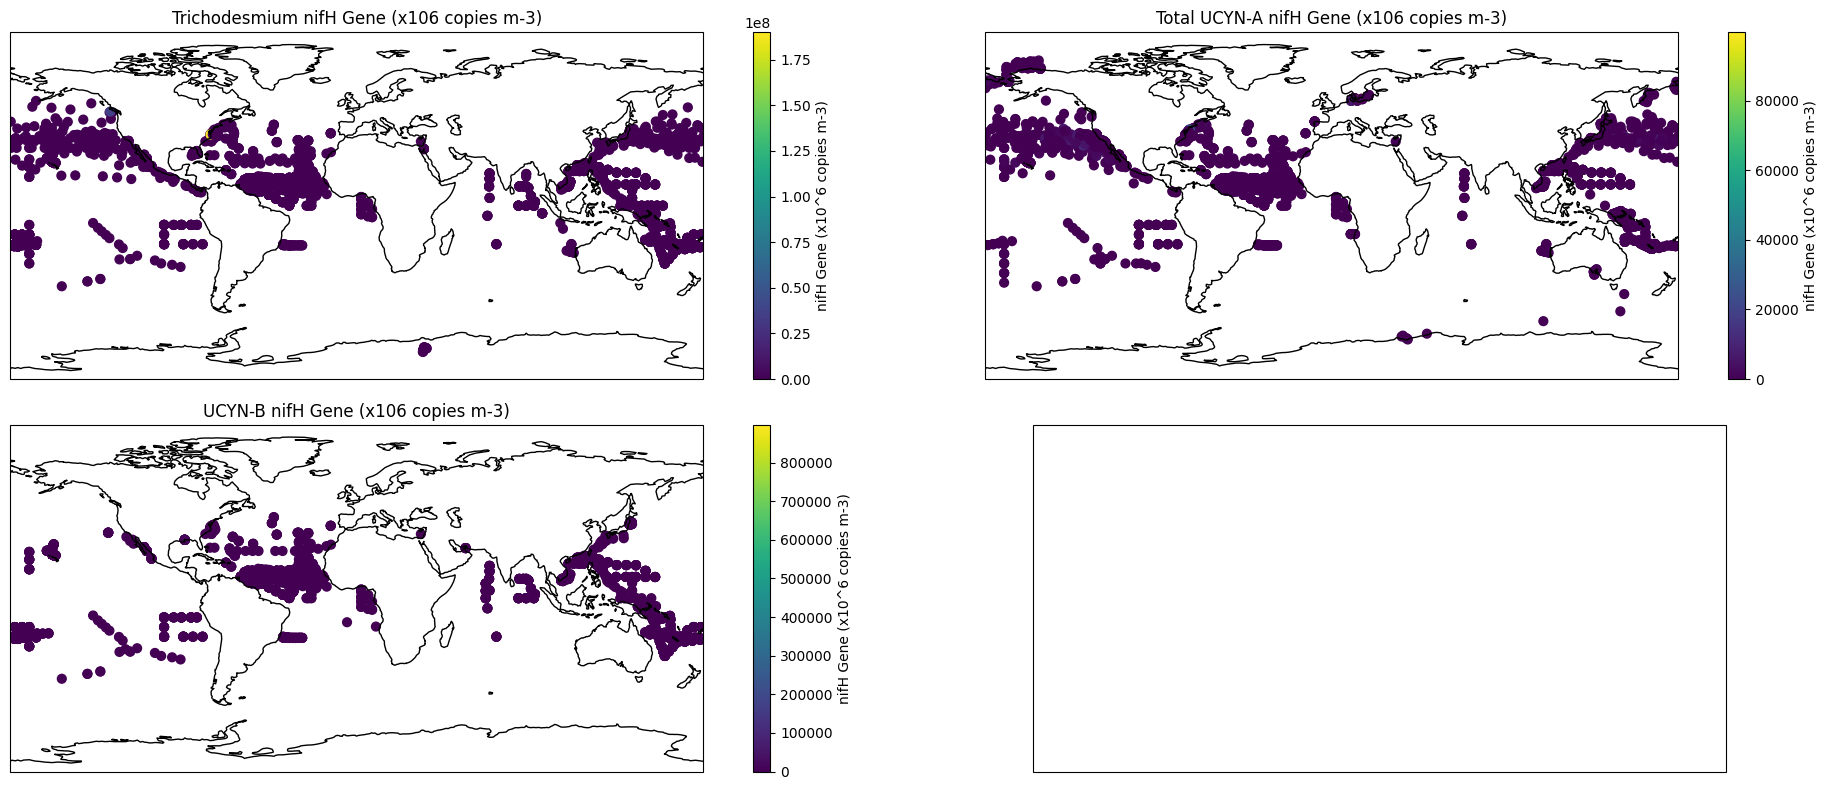

In [32]:

#we also want to plot the contents of the dataset on the map
bact_cols = ['Trichodesmium nifH Gene (x106 copies m-3)', 'Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)']
plotColsOnMap(bact_cols, dzdb_2024_nifh)

In [33]:



#since we only want to work with data from the first 25m this needs to be filtered for
dzdb_2024_nifh_depthmask = (dzdb_2024_nifh["DEPTH (m)"] <=25)
dzdb_2024_nifh_df = dzdb_2024_nifh[dzdb_2024_nifh_depthmask]

#here result stats can be seen
print(dzdb_2024_nifh_df.columns)
dzdb_2024_nifh_df.info()

Index(['LATITUDE', 'LONGITUDE', 'DEPTH (m)',
       'Trichodesmium nifH Gene (x106 copies m-3)',
       'Total UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 3064 entries, 0 to 5578
Data columns (total 6 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   LATITUDE                                   3064 non-null   float64
 1   LONGITUDE                                  3064 non-null   float64
 2   DEPTH (m)                                  3064 non-null   float64
 3   Trichodesmium nifH Gene (x106 copies m-3)  1789 non-null   float64
 4   Total UCYN-A nifH Gene (x106 copies m-3)   1919 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)         1403 non-null   float64
dtypes: float64(6)
memory usage: 167.6 KB


As a result we got a significantly smaller number of entries, which is especially seen with the data columns. But now we only have the data we actually want and need.

In [34]:
dzdb_2024_nifh_df.describe()

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Total UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3)
count,3064.000000,3064.000000,3064.000000,1.789000e+03,1919.000000,1403.000000
mean,19.707448,-11.534360,6.947879,1.272132e+05,426.088841,1372.586068
std,26.992528,125.869533,7.263417,4.572887e+06,3070.100360,26245.050587
min,-75.950000,-179.630000,0.000000,0.000000e+00,0.000000,0.000000
25%,8.952500,-132.560000,2.000000,1.190000e+00,0.270000,0.000000
50%,22.750000,-35.195000,5.000000,1.810000e+01,6.490000,1.146000
75%,35.130000,128.600000,10.000000,1.415000e+02,104.980000,22.803000
max,119.830000,187.330000,25.000000,1.900000e+08,99700.000000,898000.000000


In [35]:
removeEmptyRows(['Trichodesmium nifH Gene (x106 copies m-3)','Total UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)'],dzdb_2024_nifh_df)
dzdb_2024_nifh_df.shape

/tmp/ipykernel_221954/1221012906.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=cols, how='all', inplace=True)


(2476, 6)

# Second dataset
This is the dataset from the  [Database of diazotrophs in global ocean: abundance, biomass and nitrogen fixation rates](https://doi.pangaea.de/10.1594/PANGAEA.774851)

In [36]:
#here we open the dataset of the other database for cell count
maredat_nifh = pd.read_csv("./csv/MAREDAT_diazotroph_nifh.csv")
print(maredat_nifh.shape)
print(maredat_nifh.columns)
maredat_nifh.head()

(921, 35)
Index(['SOURCE: Data', 'SOURCE: Related article',
       'METHODS:                  Sampling/Analysis', 'DATE (yyyy-mm-dd)',
       'LATITUDE', 'LONGITUDE', 'DEPTH (m)',
       'Trichodesmium nifH Gene (x106 copies m-3)',
       'Trichodesmium Biomass Conversion factor (mg C/106 nifH copies)',
       'Trichodesmium Biomass (mg C m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-A Biomass Conversion factor (mg C/106 nifH copies)',
       'UCYN-B nifH Gene (x106 copies m-3)',
       'UCYN-B Biomass Conversion factor (mg C/106 nifH copies)',
       'UCYN-C nifH Gene (x106 copies m-3)',
       'UCYN-C Biomass Conversion factor (mg C/106 nifH copies)',
       'UCYN Biomass (mg C m-3)', 'Richelia Associated Species',
       'Richelia nifH Gene (x106 copies m-3)',
       'Richelia Biomass Conversion factor (mg C/106 nifH copies)',
       'Calothrix Associated Species',
       'Calothrix nifH Gene  (x106 copies m-3)',
       'Calothrix Biomass Conversion factor (mg C/1

,SOURCE: Data,SOURCE: Related article,METHODS: Sampling/Analysis,DATE (yyyy-mm-dd),LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),Trichodesmium Biomass Conversion factor (mg C/106 nifH copies),Trichodesmium Biomass (mg C m-3),...,Temperature (˚C),Salinity (PSU),Nitrate (µM),Phosphate (µM),Fe (nM),Chlorophyll (mg m-3),Notes,Gamma A nifH Gene (x106 copies/m3),Gamma P nifH Gene (x106 copies/m3),CIII nifH Gene (x106 copies/m3)
0,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-10-31,-9.00,-136.86,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-03,-11.51,-134.35,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-04,-13.31,-132.39,70,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-05,-15.20,-130.20,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Bonnet, S., Aix Marseille Université, sophie.b...","Bonnet et al. (2008), doi:10.5194/bg-5-215-2008",qPCR,2004-11-06,-16.87,-128.38,5,0.0,0.3,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
maredat_nifh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 921 entries, 0 to 920
Data columns (total 35 columns):
 #   Column                                                          Non-Null Count  Dtype  
---  ------                                                          --------------  -----  
 0   SOURCE: Data                                                    825 non-null    object 
 1   SOURCE: Related article                                         878 non-null    object 
 2   METHODS:                  Sampling/Analysis                     921 non-null    object 
 3   DATE (yyyy-mm-dd)                                               921 non-null    object 
 4   LATITUDE                                                        921 non-null    float64
 5   LONGITUDE                                                       921 non-null    float64
 6   DEPTH (m)                                                       921 non-null    int64  
 7   Trichodesmium nifH Gene (x106 copies m-3)            

In [38]:
removeRed(keepers, maredat_nifh)
objToNum(maredat_nifh)

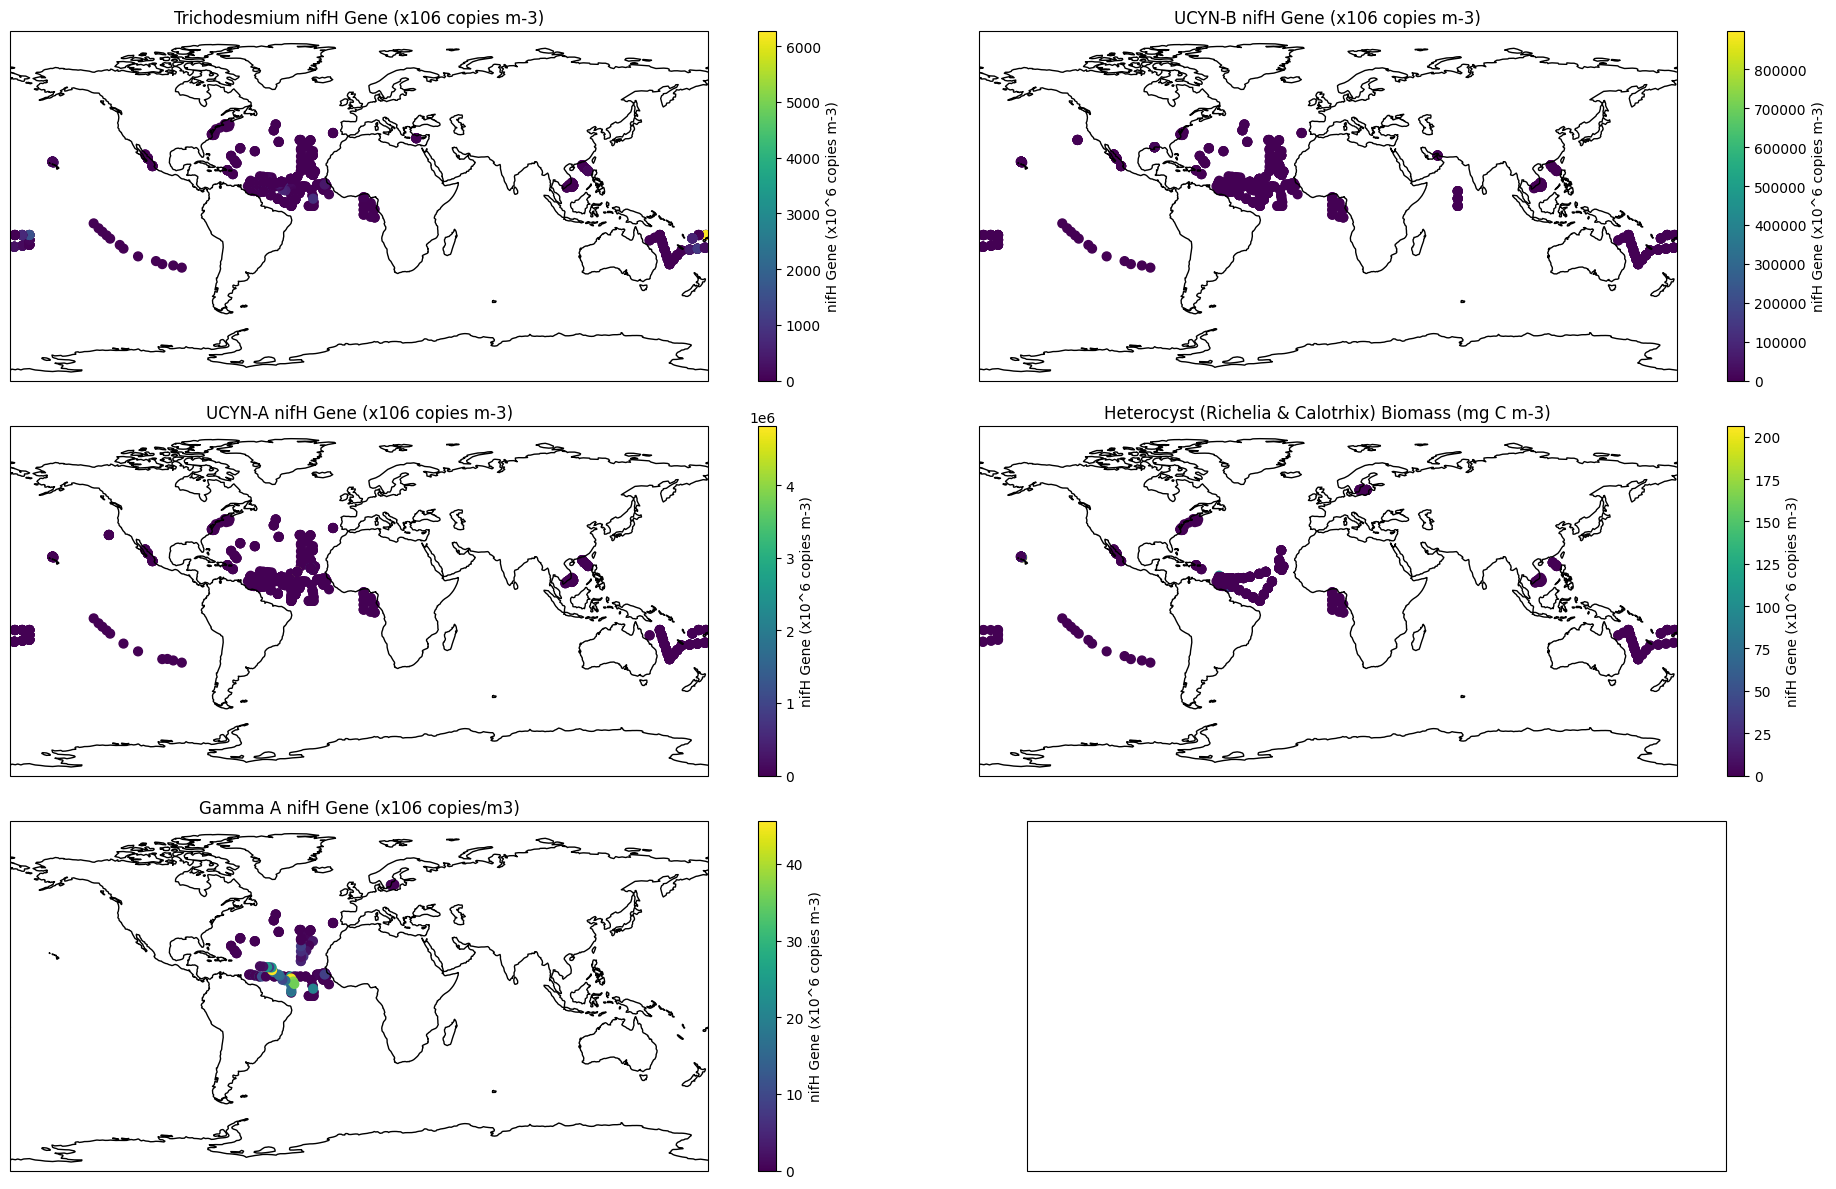

In [39]:
bact_cols =['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)',"UCYN-A nifH Gene (x106 copies m-3)","Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)", 'Gamma A nifH Gene (x106 copies/m3)']
plotColsOnMap(bact_cols, maredat_nifh)

In [40]:
#since we only want to work with data from the first 25m this needs to be filtered for
maredat_nifh_depthmask = (maredat_nifh["DEPTH (m)"] <=25)
maredat_nifh_df = maredat_nifh[maredat_nifh_depthmask]

#display result
print(maredat_nifh.columns)
maredat_nifh_df.info()

Index(['LATITUDE', 'LONGITUDE', 'DEPTH (m)',
       'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)',
       'Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)',
       'Gamma A nifH Gene (x106 copies/m3)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 450 entries, 0 to 915
Data columns (total 8 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   LATITUDE                                              450 non-null    float64
 1   LONGITUDE                                             450 non-null    float64
 2   DEPTH (m)                                             450 non-null    int64  
 3   Trichodesmium nifH Gene (x106 copies m-3)             338 non-null    float64
 4   UCYN-A nifH Gene (x106 copies m-3)                    339 non-null    float64
 5

In [41]:
maredat_nifh_df.describe()

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3),Gamma A nifH Gene (x106 copies/m3)
count,450.000000,450.000000,450.000000,338.000000,3.390000e+02,357.000000,299.000000,82.000000
mean,18.242689,-17.170578,8.053333,155.754477,3.555933e+04,4443.817921,7.750641,7.059512
std,22.913159,87.228526,7.250639,484.371625,3.637835e+05,50860.230964,27.762026,11.267062
min,-31.820000,-177.770000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.790000,-67.665000,4.000000,0.065150,0.000000e+00,0.000000,0.000100,0.182500
50%,15.650000,-29.385000,5.000000,3.065000,5.350000e-01,0.010000,0.010700,0.830000
75%,30.300000,17.500000,12.250000,66.080725,3.359110e+01,9.700000,0.339850,10.342500
max,57.380000,178.750000,25.000000,6266.844800,4.810000e+06,898000.000000,206.099800,45.550000


In [42]:
mar_cols = ['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)','Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)','Gamma A nifH Gene (x106 copies/m3)']
removeEmptyRows(mar_cols,maredat_nifh_df)

maredat_nifh_df.shape

/tmp/ipykernel_221954/1221012906.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=cols, how='all', inplace=True)


(450, 8)

# Combining both of them together into 1

In [43]:
rename_map = {"Total UCYN-A nifH Gene (x106 copies m-3)":"UCYN-A nifH Gene (x106 copies m-3)"}

renamed_set = dzdb_2024_nifh_df.rename(columns=rename_map)
combined_df = pd.concat([renamed_set, maredat_nifh_df])

combined_df.head()
#combined_df.fillna(1000, inplace=True)

,LATITUDE,LONGITUDE,DEPTH (m),Trichodesmium nifH Gene (x106 copies m-3),UCYN-A nifH Gene (x106 copies m-3),UCYN-B nifH Gene (x106 copies m-3),Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3),Gamma A nifH Gene (x106 copies/m3)
0,-9.00,-136.86,5.0,0.0,0.03,0.0,NaN,NaN
1,-11.51,-134.35,5.0,0.0,0.00,0.0,NaN,NaN
3,-15.20,-130.20,5.0,0.0,0.00,0.0,NaN,NaN
4,-16.87,-128.38,5.0,0.0,0.00,0.0,NaN,NaN
5,-20.13,-123.41,5.0,0.0,NaN,0.0,NaN,NaN


In [44]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2926 entries, 0 to 915
Data columns (total 8 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   LATITUDE                                              2926 non-null   float64
 1   LONGITUDE                                             2926 non-null   float64
 2   DEPTH (m)                                             2926 non-null   float64
 3   Trichodesmium nifH Gene (x106 copies m-3)             2127 non-null   float64
 4   UCYN-A nifH Gene (x106 copies m-3)                    2258 non-null   float64
 5   UCYN-B nifH Gene (x106 copies m-3)                    1760 non-null   float64
 6   Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)  299 non-null    float64
 7   Gamma A nifH Gene (x106 copies/m3)                    82 non-null     float64
dtypes: float64(8)
memory usage: 205.7 KB


In [45]:
bact_cols=['Trichodesmium nifH Gene (x106 copies m-3)','UCYN-A nifH Gene (x106 copies m-3)','UCYN-B nifH Gene (x106 copies m-3)','Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)','Gamma A nifH Gene (x106 copies/m3)']

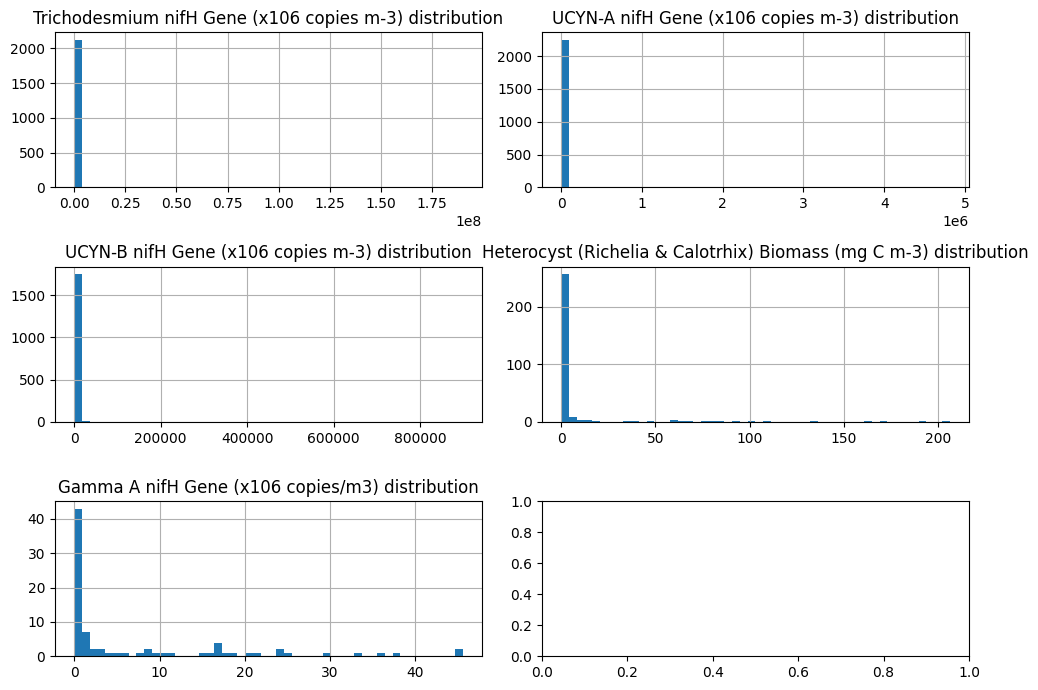

In [46]:
#I want to see the distributions of each variable to see what we are working with 
figure, axis = plt.subplots(3, 2, figsize = (10,7))

#i want to see distributions of the points
axes = axis.flatten()
for i, bact in enumerate(bact_cols):
    title = bact+" distribution"
    ax = axes[i]
    
    combined_df[bact].hist(bins=50,ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [47]:
combined_avg = combined_df.groupby(by=['LATITUDE', 'LONGITUDE']).mean()#first check for nulls and maybe fill them in before averaging
combined_avg.info()
print(combined_avg.columns)

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1472 entries, (-75.95, 34.39) to (119.83, 24.81)
Data columns (total 6 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   DEPTH (m)                                             1472 non-null   float64
 1   Trichodesmium nifH Gene (x106 copies m-3)             1154 non-null   float64
 2   UCYN-A nifH Gene (x106 copies m-3)                    1132 non-null   float64
 3   UCYN-B nifH Gene (x106 copies m-3)                    692 non-null    float64
 4   Heterocyst (Richelia & Calotrhix) Biomass (mg C m-3)  179 non-null    float64
 5   Gamma A nifH Gene (x106 copies/m3)                    81 non-null     float64
dtypes: float64(6)
memory usage: 93.8 KB
Index(['DEPTH (m)', 'Trichodesmium nifH Gene (x106 copies m-3)',
       'UCYN-A nifH Gene (x106 copies m-3)',
       'UCYN-B nifH Gene (x106 copies m-3)',
       'H

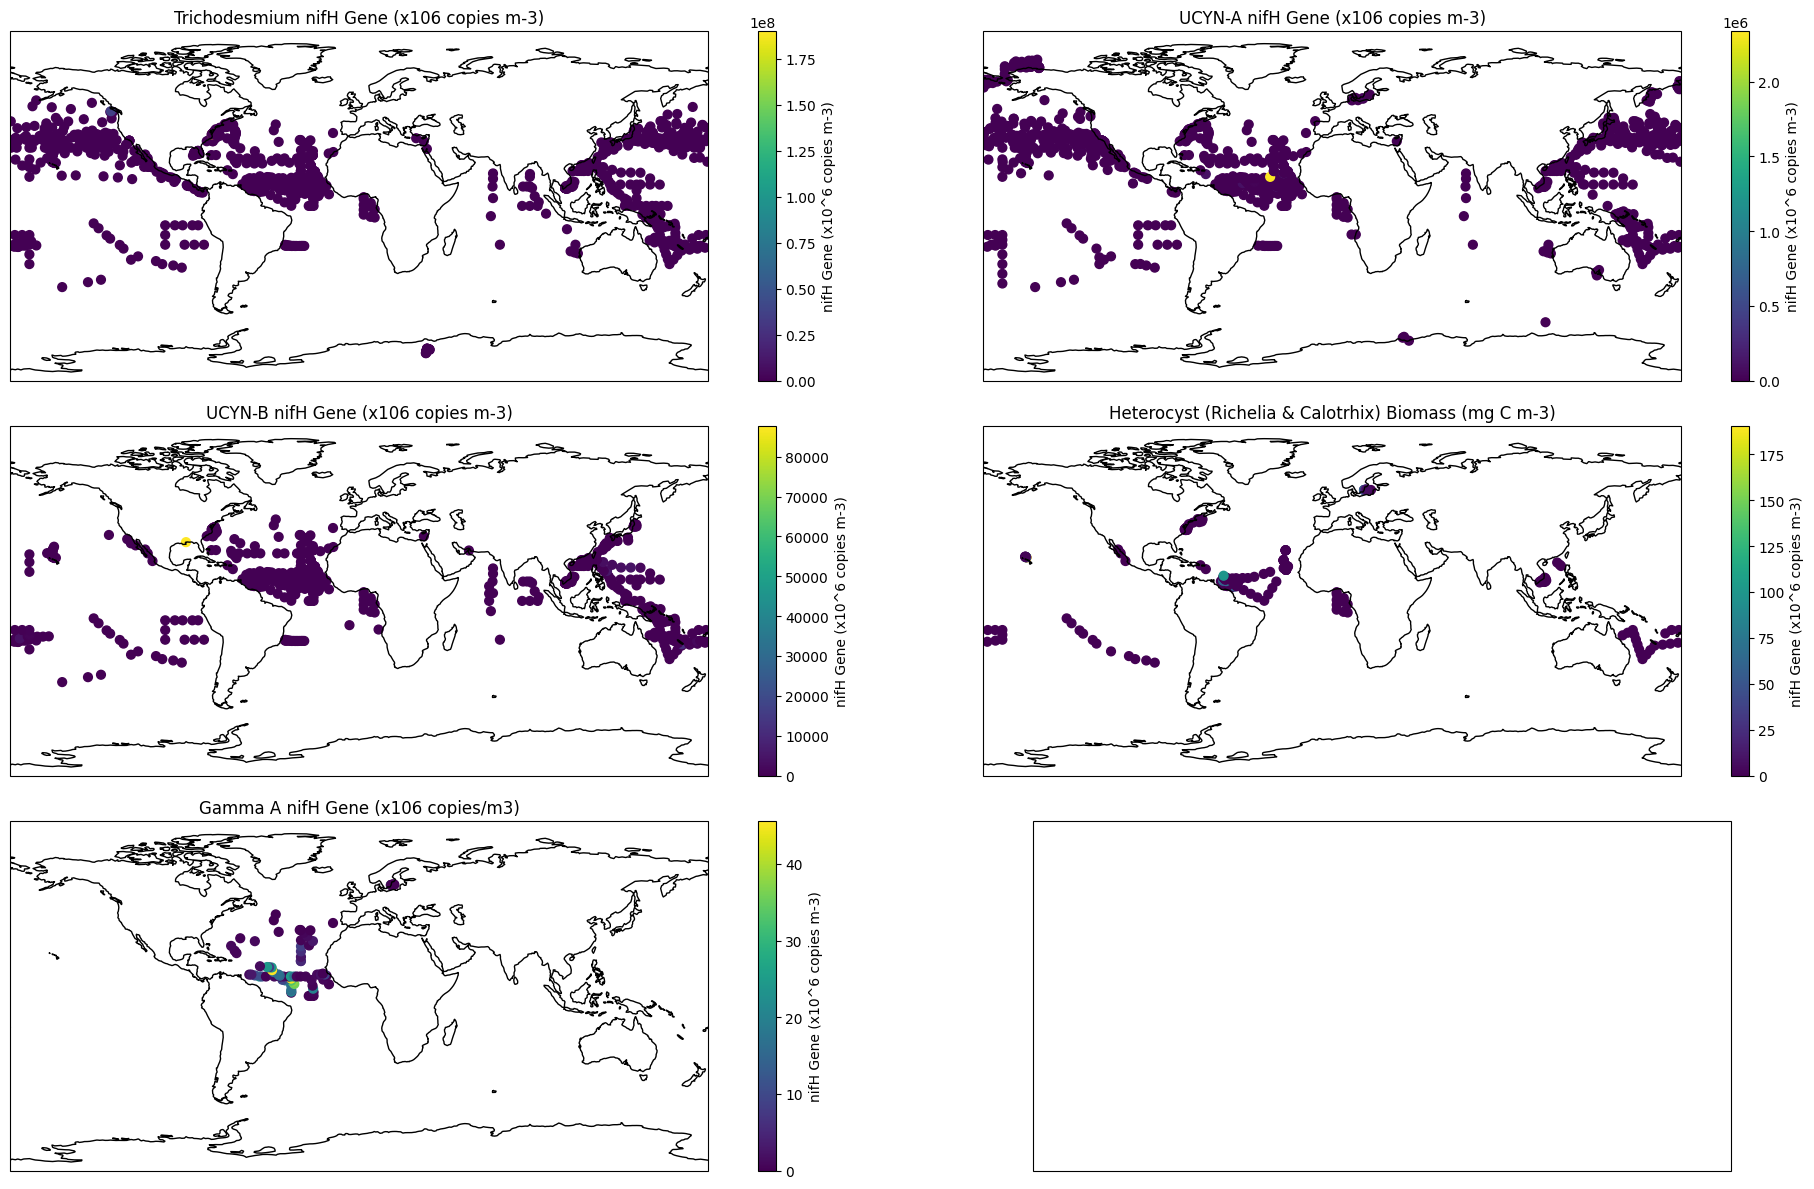

In [48]:
plotColsOnMap(bact_cols,combined_avg)

## Plotting the resulting data

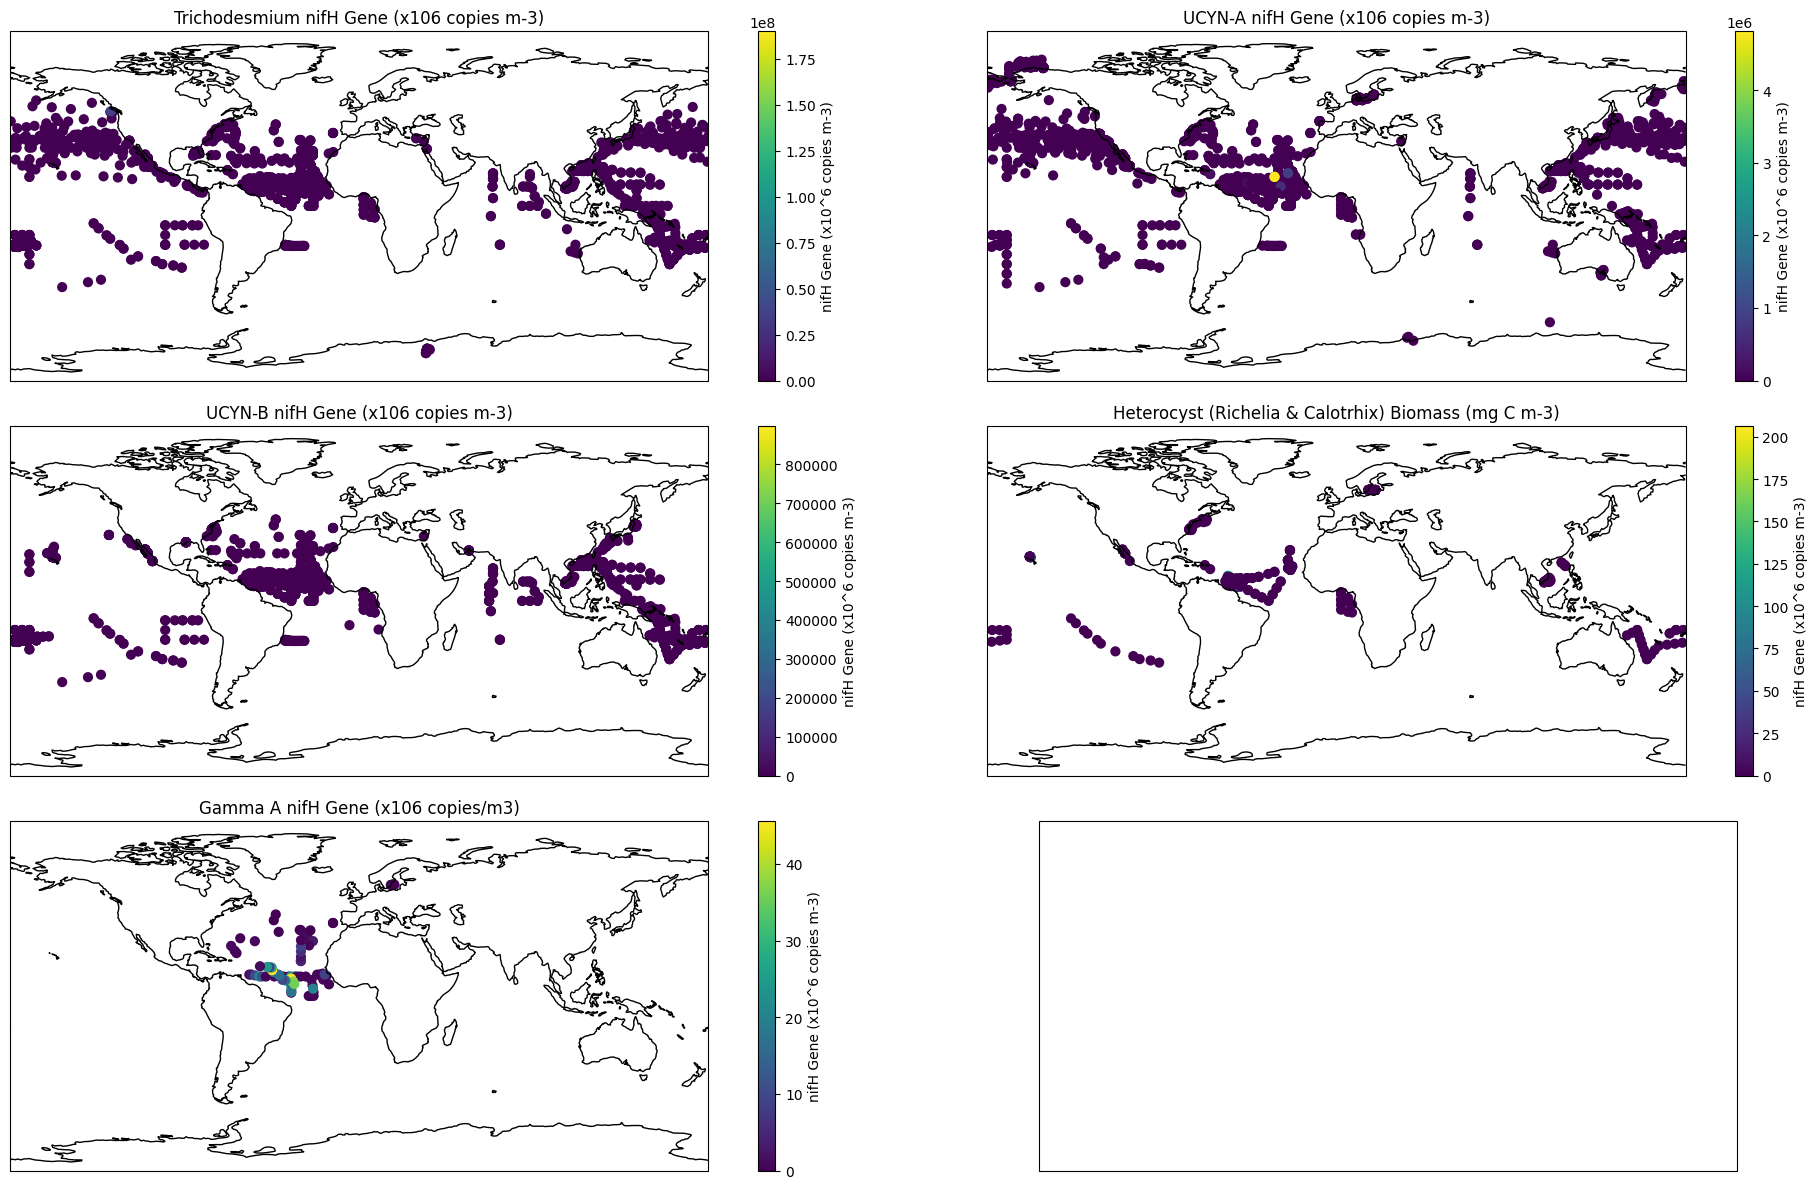

In [49]:
plotColsOnMap(bact_cols, combined_df)